# American Option Pricing via Longstaff-Schwartz (LSMC)

## Problem

Price an American put option on a non-dividend-paying stock under the Black-Scholes dynamics

$$
dS_t = r S_t\,dt + \sigma S_t\,dW_t
$$

by Monte Carlo. Unlike a European option, the holder may exercise at any of a discrete set of dates
before maturity, so the payoff at each date depends on an optimal stopping decision: exercise now for
`max(K - S_t, 0)`, or continue holding for an expected discounted continuation value. The continuation
value has no closed form once early exercise is allowed, which is what makes this harder than pricing
a European option by simulation.

## Method

**Longstaff & Schwartz (2001), "Valuing American Options by Simulation: A Simple Least-Squares
Approach"** (*Review of Financial Studies*, 14(1), 113-147) estimate the continuation value at each
exercise date by cross-sectional regression, using only the simulated paths that are already
in-the-money at that date (out-of-the-money paths have no exercise decision to make, and including them
only adds noise to the regression).

Algorithm, applied backward from maturity to `t=0`:

1. Simulate `N` risk-neutral GBM paths on a grid of `M` exercise dates per year, `S_t = S_0
   \exp((r-\tfrac12\sigma^2)t + \sigma W_t)`.
2. Initialize the cash flow of every path to its payoff at maturity, `\max(K-S_T,0)`.
3. Step backward through each exercise date `t_j`. Among the paths in-the-money at `t_j`, regress the
   realized (discounted-back-to-`t_j`) future cash flow on a small basis of **weighted Laguerre
   polynomials** evaluated at `S_{t_j}/K`:
   $$
   L_0(x) = e^{-x/2}, \quad L_1(x) = e^{-x/2}(1-x), \quad L_2(x) = e^{-x/2}\left(1 - 2x +
   \tfrac{x^2}{2}\right)
   $$
   The fitted value is the estimated continuation value.
4. Compare it to the immediate exercise value `K - S_{t_j}`. Where exercise is optimal (immediate
   value exceeds the estimated continuation value), overwrite that path's cash flow with the exercise
   value and record the exercise time; otherwise leave the path's existing (later) cash flow untouched.
5. After processing every exercise date, discount each path's realized cash flow back to `t=0` from its
   own exercise time and average over all paths.

The regression itself (`numpy.linalg.lstsq`) is the only library shortcut used — the backward
induction, in-the-money masking, and exercise decision are implemented directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

rng = np.random.default_rng(0)

# Contract / market parameters shared across all cases (Longstaff-Schwartz 2001, Table 1)
K = 40.0        # strike
r = 0.06        # risk-free rate
steps_per_year = 50

In [2]:
def simulate_gbm_paths(S0, sigma, T, n_steps, n_paths, rng):
    """Risk-neutral GBM paths, shape (n_paths, n_steps + 1), column 0 = S0."""
    dt = T / n_steps
    Z = rng.standard_normal((n_paths, n_steps))
    increments = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_paths = np.cumsum(increments, axis=1)
    S = np.empty((n_paths, n_steps + 1))
    S[:, 0] = S0
    S[:, 1:] = S0 * np.exp(log_paths)
    return S

In [3]:
def laguerre_basis(x):
    """Weighted Laguerre polynomials L0, L1, L2 evaluated at x = S/K."""
    w = np.exp(-x / 2.0)
    L0 = w
    L1 = w * (1 - x)
    L2 = w * (1 - 2 * x + x**2 / 2)
    return np.column_stack([L0, L1, L2])

In [4]:
def price_american_put_lsmc(S0, sigma, T, n_paths=100_000, steps_per_year=steps_per_year, rng=rng):
    n_steps = int(round(steps_per_year * T))
    dt = T / n_steps
    S = simulate_gbm_paths(S0, sigma, T, n_steps, n_paths, rng)

    payoff = lambda s: np.maximum(K - s, 0.0)

    cashflow = payoff(S[:, -1])          # cash flow realized by each path, updated as we find earlier exercise
    exercise_step = np.full(n_paths, n_steps)  # step index (not time) at which each path's cashflow occurs

    for j in range(n_steps - 1, 0, -1):        # exercise dates t_1 .. t_{n_steps-1} (t_0 excluded: nothing to regress on)
        itm = payoff(S[:, j]) > 0
        if not np.any(itm):
            continue

        x = S[itm, j] / K
        Y = cashflow[itm] * np.exp(-r * dt * (exercise_step[itm] - j))
        basis = laguerre_basis(x)
        coeffs, *_ = np.linalg.lstsq(basis, Y, rcond=None)
        continuation = basis @ coeffs

        exercise_value = payoff(S[itm, j])
        exercise_now = exercise_value > continuation

        idx = np.where(itm)[0][exercise_now]
        cashflow[idx] = exercise_value[exercise_now]
        exercise_step[idx] = j

    discounted = cashflow * np.exp(-r * dt * exercise_step)
    price = discounted.mean()
    stderr = discounted.std(ddof=1) / np.sqrt(n_paths)
    return price, stderr, S, exercise_step

In [5]:
def bs_put(S0, K, r, sigma, T):
    """Closed-form European put (Black-Scholes), used as a lower-bound cross-check."""
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)

## Validation against Longstaff & Schwartz (2001), Table 1

Reference values below are taken directly from Table 1 of the paper: the European closed-form price,
the paper's own simulated American price, and their finite-difference "true" American price (a
high-resolution binomial/finite-difference benchmark used as ground truth in the paper).

In [6]:
cases = [
    # S0,  sigma, T,  LS_paper_american, LS_paper_finite_difference
    (36.0, 0.20, 1.0, 4.472, 4.478),
    (36.0, 0.20, 2.0, 4.821, 4.840),
    (36.0, 0.40, 1.0, 7.091, 7.101),
    (40.0, 0.20, 1.0, 2.313, 2.314),
    (44.0, 0.40, 2.0, 5.622, 5.647),
]

rows = []
for S0, sigma, T, ls_paper, fd_paper in cases:
    price, se, _, _ = price_american_put_lsmc(S0, sigma, T)
    euro = bs_put(S0, K, r, sigma, T)
    rows.append({
        "S0": S0, "sigma": sigma, "T": T,
        "European (closed-form)": round(euro, 3),
        "American (this notebook)": round(price, 3),
        "std. error": round(se, 4),
        "American (Longstaff-Schwartz 2001)": ls_paper,
        "American (finite-difference benchmark)": fd_paper,
    })

results = pd.DataFrame(rows)
results

,S0,sigma,T,European (closed-form),American (this notebook),std. error,American (Longstaff-Schwartz 2001),American (finite-difference benchmark)
0,36.0,0.2,1.0,3.844,4.473,0.0092,4.472,4.478
1,36.0,0.2,2.0,3.763,4.815,0.0110,4.821,4.840
2,36.0,0.4,1.0,6.711,7.055,0.0188,7.091,7.101
3,40.0,0.2,1.0,2.066,2.302,0.0087,2.313,2.314
4,44.0,0.4,2.0,5.202,5.636,0.0206,5.622,5.647


Every case satisfies `European <= American (this notebook) <= American (finite-difference
benchmark) + a few std. errors`, consistent with the early-exercise premium being strictly positive
and the simulation estimate bracketing the finite-difference reference within Monte Carlo noise.

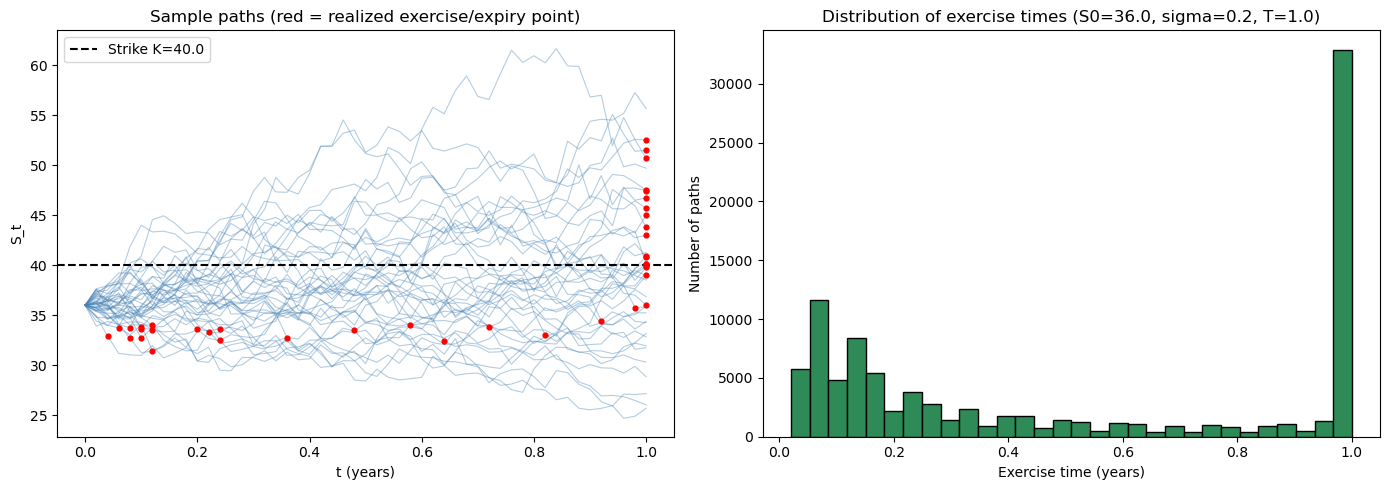

Price for S0=36.0, sigma=0.2, T=1.0: 4.4622 (std. error 0.0092)
Fraction of paths exercised before maturity: 0.687


In [7]:
S0, sigma, T = 36.0, 0.20, 1.0
price, se, S, exercise_step = price_american_put_lsmc(S0, sigma, T, n_paths=100_000)
n_steps = S.shape[1] - 1
dt = T / n_steps
time_grid = np.linspace(0, T, n_steps + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# A handful of sample paths, with a marker at each path's realized exercise/expiry time
sample = rng.choice(S.shape[0], 40, replace=False)
for i in sample:
    axes[0].plot(time_grid, S[i], color='steelblue', alpha=0.4, linewidth=0.8)
    axes[0].scatter(exercise_step[i] * dt, S[i, exercise_step[i]], color='red', s=12, zorder=3)
axes[0].axhline(K, color='black', linestyle='--', label=f'Strike K={K}')
axes[0].set_xlabel('t (years)')
axes[0].set_ylabel('S_t')
axes[0].set_title('Sample paths (red = realized exercise/expiry point)')
axes[0].legend()

axes[1].hist(exercise_step * dt, bins=30, color='seagreen', edgecolor='black')
axes[1].set_xlabel('Exercise time (years)')
axes[1].set_ylabel('Number of paths')
axes[1].set_title(f'Distribution of exercise times (S0={S0}, sigma={sigma}, T={T})')

plt.tight_layout()
plt.savefig('lsmc_exercise_behavior.png', dpi=110)
plt.show()

print(f"Price for S0={S0}, sigma={sigma}, T={T}: {price:.4f} (std. error {se:.4f})")
print(f"Fraction of paths exercised before maturity: {(exercise_step < n_steps).mean():.3f}")